<br>
<div style="text-align:center">
    <img src="https://drive.google.com/uc?export=view&id=1Pdw9tSfoLWFJsdCtZE1jJlpY2tPM04K-">
<br>
</div>   





<h1  style="text-align:center;font-size:.95em;font-style:normal;font-weight:300;line-height:1.5;">This notebook aims to predict home prices by analyzing both pictures of the properties and numerical details like the number of bedrooms and bathrooms. We've opted to use a combination of two types of neural networks: a Convolutional Neural Network (CNN) for the image analysis and a Multilayer Perceptron (MLP) for crunching the numbers. After both neural networks have done their work, we merge their results into a final layer that provides us with a price prediction.
</h1>


<br>



>1. <span style="color:#4c4c4c;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Read Data In and Set Attributes](#1.-Read-Data-In-and-Set-Attributes)  <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[user inputs required]</span>
>2. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [A Nice Sample View of the Images for Each Home in the Dataset](#2.-A-Nice-Sample-View-of-the-Images-for-Each-Home-in-the-Dataset) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[no user input or changes required]</span>
>3. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Set Split, Generate Train/Test Datasets](#3.-Set-Split,-Generate-Train/Test-Datasets) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[user inputs required]</span>
>4. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Set Both the MLP and CNN](#4.-Set-Both-the-MLP-and-CNN) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[user inputs required]</span>
>5. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Set Epochs and Batch Size Then Train the Model and Log Metrics and Artifacts to MLFlow](#5.-Set-Epochs-and-Batch-Size-Then-Train-the-Model-and-Log-Metrics-and-Artifacts-to-MLFlow) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[user inputs required]</span>
>6. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Verify MLFlow Inputs](#6.-Verify-MLFlow-Inputs) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[no user input or changes required]</span>
>7. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Plot Results Including Actual vs. Predicted Prices](#7.-Plot-Results-Including-Actual-vs.-Predicted-Prices) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[user inputs required]</span>
>8. <span style="color:#55E7B2;font-size:.95em;font-weight:900;line-height:2.5;">&#9679;&nbsp;</span> [Plot Results Including Training & Validation Loss](#8.-Plot-Results-Including-Training-&-Validation-Loss) <span style="color:#4c4c4c;font-size:.75em;font-weight:300;">[user inputs required]</span>

<span style="color:#f3f3f3f;font-size:.95em;font-weight:300;">⸺</span> 
<br>
<span style="color:#4c4c4c;font-size:.75em;font-weight:900;">&#9679;</span>
 <span style="color:#f3f3f3f;font-size:.95em;font-weight:300;"> requires input</span> 
<br>
<span style="color:#7AB07B;font-size:.75em;font-weight:900;">&#9679;</span>
 <span style="color:#f3f3f3f;font-size:.95em;font-weight:300;"> no user input or changes required</span>


In [72]:
from helper import *


src/homePrices.csv


## 1. Read Data in and Set Attributes
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To read the housing dataset and set the attributes such as Bedroom max, Square footage max, Price max, Bath max, etc.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can load the dataset and set initial filtering conditions based on the attributes mentioned.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output is a filtered dataset ready for further processing.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">Make sure to check the validity of data points before and after setting the attributes.</span></p>


In [73]:
df = readData()
bM, sqftM, priceM, bathM, citiM, xHouseAttributes = setAttributes(df)



## 2. A Nice Sample View of the Images for Each Home in the Dataset
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To visualize a sample set of images for each home in the dataset.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can display a set of images for a quick inspection and understanding of the dataset.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output is a visual gallery of home images.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">Useful for manual verification and for gaining insights into the visual aspect of the dataset.</span></p>


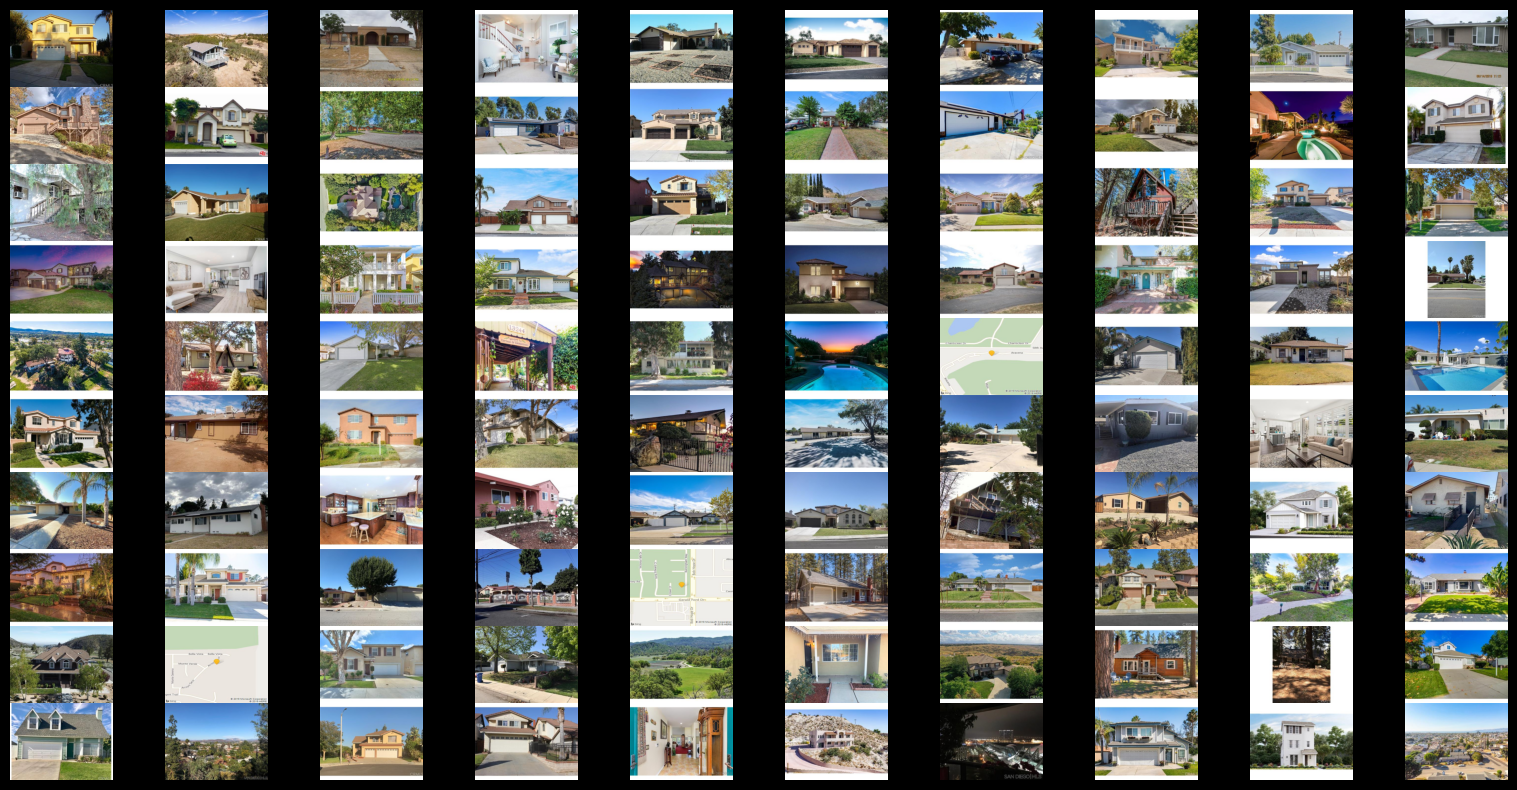

In [74]:
plotSampleImages()

## 3. Set Split, Generate Train/Test Datasets
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To partition the dataset into training and test sets.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can generate train and test datasets based on a given split ratio.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output includes separate training and test datasets for further modeling.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">Ensure that the datasets are balanced and representative of the overall data.</span></p>


In [75]:
cnt=0
images_path='img'
xHouseImg=np.zeros((15474,64,64,3),dtype='uint32')
for i in range(15474):

    sample=cv2.imread(images_path+'/'+str(i)+'.jpg')
    imgs=cv2.resize(sample,(64,64))
    xHouseImg[cnt]=imgs
    cnt+=1
    print(f"{cnt:,}",end='\r')
print(f"Image Count: {cnt:,}")
xHouseImg=xHouseImg/255.0

Image Count: 15,474


In [76]:
#set split, train/test, etc. 
split = train_test_split(xHouseAttributes, xHouseImg, test_size=0.25, random_state=42)
(Xatt_train,Xatt_test,Ximage_train,Ximage_test) = split

y_train , y_test = Xatt_train['price'].values , Xatt_test['price'].values

X1_train=Xatt_train[['n_citi','bed','bath','sqft']].values
X2_train=Ximage_train
X1_test=Xatt_test[['n_citi','bed','bath','sqft']].values
X2_test=Ximage_test


## 4. Set Both the MLP and CNN, Create the Input to Final Set of Layers
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To set up the architecture for both MLP and CNN models and integrate them into a final set of fully connected layers.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell is capable of configuring the MLP and CNN architectures and combining their outputs for further processing.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output is a model with integrated MLP and CNN architectures, ready for training.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">Ensure that the architectures are compatible and that the final fully connected layers are set up properly.</span></p>


In [77]:
#set both the mlp and cnn
mlp = createANN(X1_train.shape[1], regress=False)
cnn = createCNN(64, 64, 3, regress=False)

# create the input to our final set of layers as the output of both the MLP and CNN
combinedInput = concatenate([mlp.output, cnn.output])

# our final FC layer head will have two dense layers, the final one will be the regressor
x = Dense(4, activation="relu")(combinedInput)
x = Dense(1, activation="linear")(x)

## 5. Set Epochs and Batch Size Then Train the Model and Log Metrics and Artifacts to MLFlow
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To define training parameters such as epochs and batch size, and to initiate the training process.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can set the number of epochs and batch size, train the model, and log metrics and artifacts to MLFlow.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output includes a trained model along with logged metrics and artifacts in MLFlow.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">Monitor the training process to avoid overfitting or underfitting.</span></p>


In [78]:


epochs = 100
batch_size = 77

model = Model(inputs=[mlp.input, cnn.input], outputs=x)
opt = Adam(lr=1e-3, decay=1e-3 / 200)
model.compile(loss="mse", optimizer=opt)
print("...training model")

history = model.fit(x=[X1_train,X2_train], 
                    y=y_train, 
                    validation_data=([X1_test, X2_test], 
                    y_test), 
                    epochs=epochs, 
                    batch_size=batch_size)


experiment_name = f"House Prices Experiment {np.random.randint(100,999)}"
mlflow.set_experiment(experiment_name)

with mlflow.start_run() as run:
    # Log parameters and metrics
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_metric("loss", history.history["loss"][-1])  
    mlflow.log_metric("val_loss", history.history["val_loss"][-1])          
    mlflow.pyfunc.log_model('housePrices_saved_model', "housePrices_model")
    run_id = run.info.run_id
    experiment_id = run.info.experiment_id
    print(f"Metrics have been logged to Run ID: {run_id} in Experiment: {experiment_name} (id: {experiment_id})")
    mlflow.end_run()

model.save('src/housePrices.h5')

client = mlflow.tracking.MlflowClient()

runs = client.search_runs(experiment_ids=[experiment_id])

for run in runs:
    run_id = run.info.run_id
    metrics = client.get_run(run_id).data.metrics
    params = client.get_run(run_id).data.params
    tags = client.get_run(run_id).data.tags
    experiment_id = run.info.experiment_id
    
    print(f"For Run ID: {run_id} in Experiment ID: {experiment_id}")
    print(f"Metrics: {metrics}")
    print(f"Parameters: {params}")
    print(f"Tags: {tags}")



/Users/cassidyhilton/opt/anaconda3/envs/new/lib/python3.11/site-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


...training model
Epoch 1/100
151/151 [==============================] - 13s 81ms/step - loss: 0.1875 - val_loss: 0.1204
Epoch 2/100
151/151 [==============================] - 11s 73ms/step - loss: 0.0672 - val_loss: 0.0817
Epoch 3/100
151/151 [==============================] - 10s 67ms/step - loss: 0.0473 - val_loss: 0.0565
Epoch 4/100
151/151 [==============================] - 11s 73ms/step - loss: 0.0390 - val_loss: 0.0430
Epoch 5/100
151/151 [==============================] - 11s 71ms/step - loss: 0.0355 - val_loss: 0.0342
Epoch 6/100
151/151 [==============================] - 10s 64ms/step - loss: 0.0311 - val_loss: 0.0301
Epoch 7/100
151/151 [==============================] - 10s 68ms/step - loss: 0.0276 - val_loss: 0.0260
Epoch 8/100
151/151 [==============================] - 10s 68ms/step - loss: 0.0257 - val_loss: 0.0248
Epoch 9/100
151/151 [==============================] - 10s 66ms/step - loss: 0.0244 - val_loss: 0.0254
Epoch 10/100
151/151 [==============================] -

2023/10/08 15:51:09 INFO mlflow.tracking.fluent: Experiment with name 'House Prices Experiment 273' does not exist. Creating a new experiment.
2023/10/08 15:51:16 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /var/folders/05/vk85sv3s3g14b1msj3n3ywt40000gn/T/tmpduky2y6e/model, flavor: python_function), fall back to return ['cloudpickle==2.2.1']. Set logging level to DEBUG to see the full traceback.


Metrics have been logged to Run ID: 936fab4c179c471e9e3cda0c6154eb8c in Experiment: House Prices Experiment 273 (id: 223555761727683401)
For Run ID: 936fab4c179c471e9e3cda0c6154eb8c in Experiment ID: 223555761727683401
Metrics: {'val_loss': 0.02383272908627987, 'loss': 0.004207306075841188}
Parameters: {'epochs': '100', 'batch_size': '77'}
Tags: {'mlflow.user': 'cassidyhilton', 'mlflow.runName': 'calm-lamb-721', 'mlflow.source.name': '/Users/cassidyhilton/opt/anaconda3/envs/new/lib/python3.11/site-packages/ipykernel_launcher.py', 'mlflow.log-model.history': '[{"run_id": "936fab4c179c471e9e3cda0c6154eb8c", "artifact_path": "housePrices_saved_model", "utc_time_created": "2023-10-08 21:51:10.144640", "flavors": {"python_function": {"loader_module": "housePrices_model", "python_version": "3.11.5", "env": {"conda": "conda.yaml", "virtualenv": "python_env.yaml"}}}, "model_uuid": "71c04756078046d592648a7c911027ef", "mlflow_version": "2.7.1"}]', 'mlflow.source.type': 'LOCAL'}


In [79]:
#!mlflow ui
#!lsof -i :5000



## 6. Verify MLFlow Inputs
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [no input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To verify that all metrics and artifacts have been correctly logged to MLFlow.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can validate the logging status of metrics and artifacts in MLFlow.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output is a confirmation or a list of discrepancies in the logged metrics and artifacts.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">Ensure that all critical data for model evaluation and retraining are logged.</span></p>


In [80]:
client = mlflow.tracking.MlflowClient()

runs = client.search_runs(experiment_ids=[experiment_id])

for run in runs:
    run_id = run.info.run_id
    metrics = client.get_run(run_id).data.metrics
    params = client.get_run(run_id).data.params
    tags = client.get_run(run_id).data.tags
    experiment_id = run.info.experiment_id
    
    print(f"For Run ID: {run_id} in Experiment ID: {experiment_id}")
    print(f"Metrics: {metrics}")
    print(f"Parameters: {params}")
    print(f"Tags: {tags}")


For Run ID: 936fab4c179c471e9e3cda0c6154eb8c in Experiment ID: 223555761727683401
Metrics: {'val_loss': 0.02383272908627987, 'loss': 0.004207306075841188}
Parameters: {'epochs': '100', 'batch_size': '77'}
Tags: {'mlflow.user': 'cassidyhilton', 'mlflow.runName': 'calm-lamb-721', 'mlflow.source.name': '/Users/cassidyhilton/opt/anaconda3/envs/new/lib/python3.11/site-packages/ipykernel_launcher.py', 'mlflow.log-model.history': '[{"run_id": "936fab4c179c471e9e3cda0c6154eb8c", "artifact_path": "housePrices_saved_model", "utc_time_created": "2023-10-08 21:51:10.144640", "flavors": {"python_function": {"loader_module": "housePrices_model", "python_version": "3.11.5", "env": {"conda": "conda.yaml", "virtualenv": "python_env.yaml"}}}, "model_uuid": "71c04756078046d592648a7c911027ef", "mlflow_version": "2.7.1"}]', 'mlflow.source.type': 'LOCAL'}


## 7. Plot Results Including Actual vs. Predicted Prices
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To visualize the model's performance by plotting actual versus predicted prices.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can generate plots that compare the actual and predicted prices.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output is a set of plots that serve as a qualitative assessment of the model's performance.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">These plots are useful for presentations and for identifying areas of improvement in the model.</span></p>


484/484 [==============================] - 6s 11ms/step


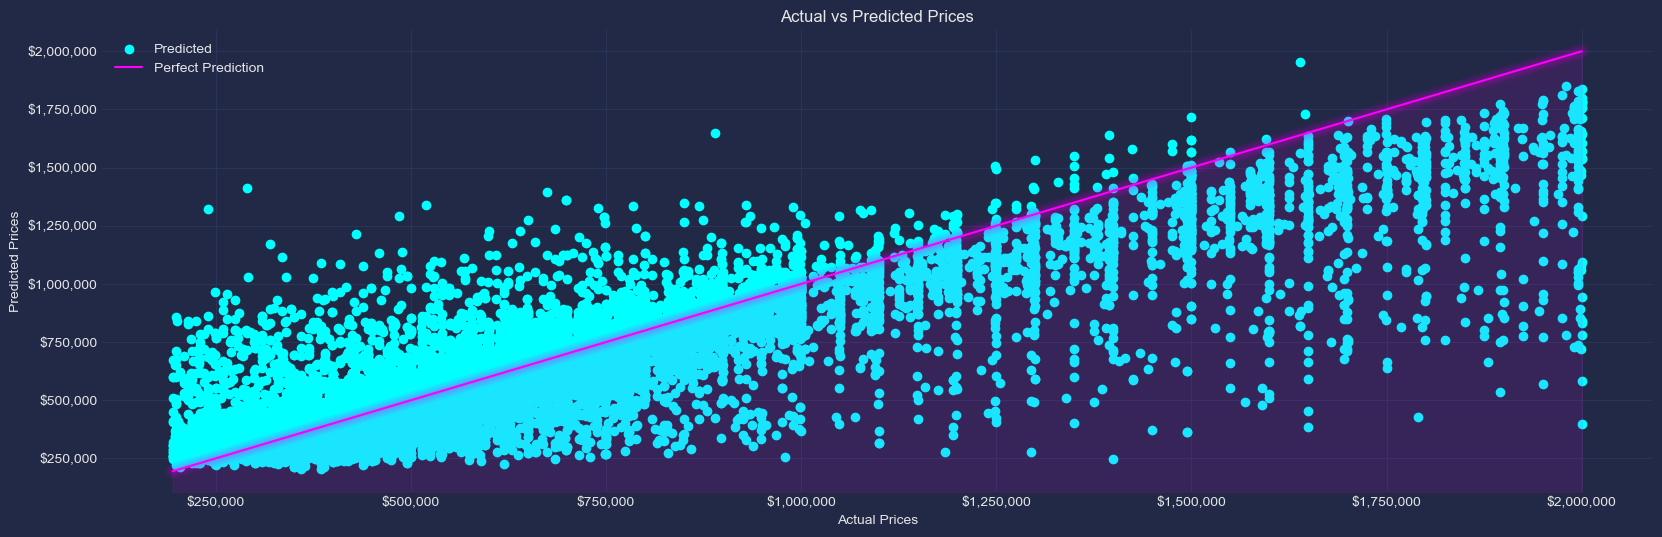

In [81]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def currency_formatter(x, pos):
    return '${:,.0f}'.format(x)

formatter = FuncFormatter(currency_formatter)

plt.style.use("cyberpunk")

# Your code for y_actual and y_pred
y_actual = df['price'].values
y_pred = model.predict([X1_final_array, X2_final_array])
y_pred_denorm = y_pred.flatten() * priceM

# Create the plot with cyberpunk style
plt.figure(figsize=(20, 6))

plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
# Plot the actual and predicted values
plt.scatter(y_actual, y_pred_denorm, c='cyan', marker='o', label='Predicted')
#plt.scatter(y_actual, y_actual, c='magenta', marker='o', label='Actual')

# Additional plot details
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')

# Line of perfect prediction
plt.plot([min(y_actual), max(y_actual)], [min(y_actual), max(y_actual)], c='magenta', label='Perfect Prediction')

# Add legend to distinguish between actual and predicted
plt.legend()

# Add the cyberpunk glow effects
mplcyberpunk.add_glow_effects()

plt.show()


## 8. Plot Results Including Training & Validation Loss
<span style="color:#7AB07B;font-size:.8em;font-weight:900;">&#9679;</span>
<span style="color:#4c4c4c;font-size:.8em;font-weight:300;"> [input required]</span>
<p><strong>Purpose:</strong> <span style="font-size:.8em;">To visualize the training and validation loss over the course of the training process.</span></p>
<p><strong>Capabilities:</strong> <span style="font-size:.8em;">This cell can plot the training and validation loss at each epoch.</span></p>
<p><strong>Outputs:</strong> <span style="font-size:.8em;">The output is a set of plots that provide insights into the model's learning process.</span></p>
<p><strong>Additional Notes:</strong> <span style="font-size:.8em;">These plots are important for diagnosing issues like overfitting or underfitting and for tuning the model.</span></p>

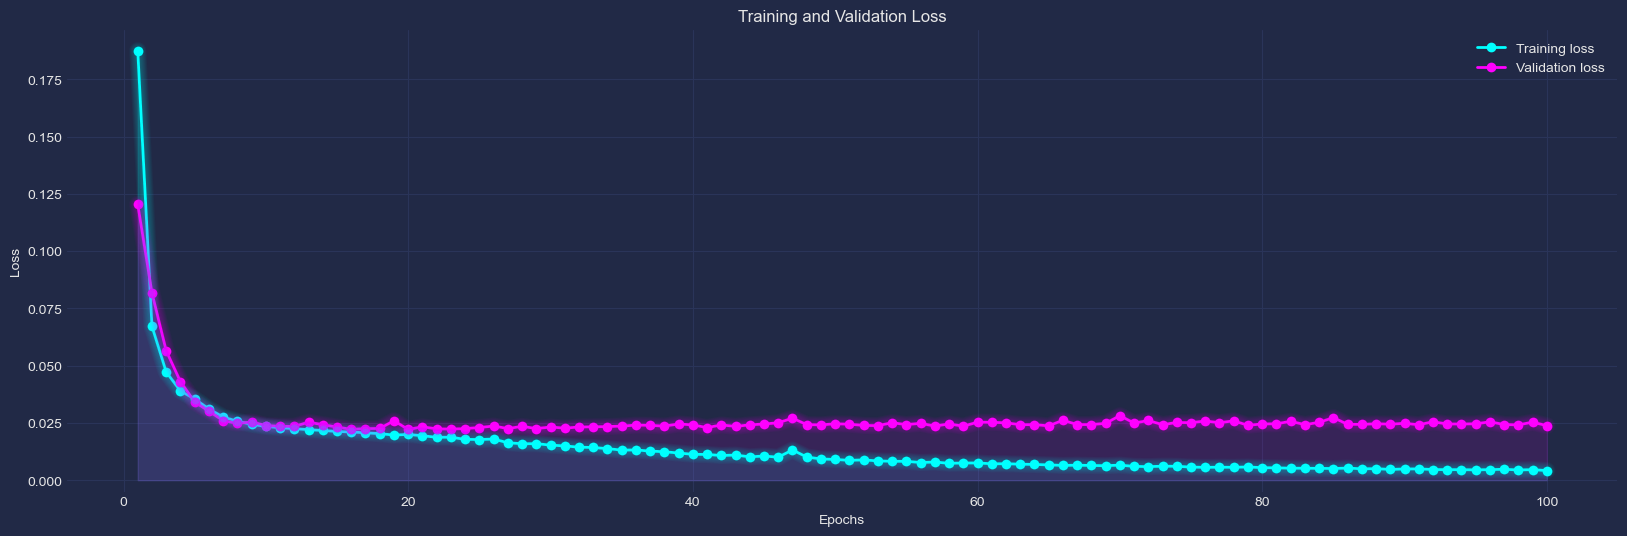

In [82]:
import mplcyberpunk

plt.style.use("cyberpunk")

# Your original plotting code
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(20, 6))

plt.plot(epochs, loss_values, color='cyan', marker='o', linestyle='-', linewidth=2, label='Training loss')
plt.plot(epochs, val_loss_values, color='magenta', marker='o', linestyle='-', linewidth=2, label='Validation loss')

# Additional plot details
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add the cyberpunk glow effects
mplcyberpunk.add_glow_effects()

plt.show()
